In [4]:
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio
import soundfile as sf
from numpy import pi
import os
import pandas as pd
from itertools import product
import uuid
from tqdm import tqdm
from collections import defaultdict
import gc
import os
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load data
---

In [47]:
import glob, numpy as np
widths = []
for p in glob.glob("augmented_data/*.npy"):
    a = np.load(p)
    if a.ndim==3: widths.append(a.shape[2])  # si (C,H,W)
    else: widths.append(a.shape[1])          # si (H,W,C)
np.percentile(widths, [0,25,50,75,100])

array([143., 157., 157., 174., 224.])

In [58]:
TARGET_HEIGHT = 64   # N_MELS
TARGET_WIDTH = 164   # TIME_STEPS deseado
TARGET_CHANNELS = 2  # mel + mfcc
IMG_SHAPE = (TARGET_HEIGHT, TARGET_WIDTH, TARGET_CHANNELS)
AUTOTUNE = tf.data.experimental.AUTOTUNE
BATCH_SIZE = 512

In [60]:
def split_label_to_binary(df, label_col='label'):
    s = df[label_col].fillna('').astype(str)

    # Caso explícito "0_1" / "1_0"
    mask_bin = s.str.match(r'^[01]_[01]$')
    df.loc[mask_bin, 'Crackles'] = s[mask_bin].str[0].astype(int)
    df.loc[mask_bin, 'Wheezes']  = s[mask_bin].str[2].astype(int)

    # Valores que aún puedan quedar vacíos (p.ej. '') -> 0
    df['Crackles'] = df['Crackles'].fillna(0).astype(int)
    df['Wheezes']  = df['Wheezes'].fillna(0).astype(int)

    return df

def np_load_npy(path):
    # path: bytes from tf -> decode to str
    p = path.decode('utf-8')
    a = np.load(p)
    # asegurarse dtype y forma
    arr = a.astype(np.float32)
    return arr

def tf_load_npy(path, label):
    img = tf.numpy_function(np_load_npy, [path], tf.float32)   # devuelve tensor con shape desconocida
    img = tf.convert_to_tensor(img)
    img = tf.transpose(img, perm=[1, 2, 0])   # (C,H,W) -> (H,W,C)
    img = tf.image.resize(img, size=[TARGET_HEIGHT, TARGET_WIDTH], method='bilinear')
    img = tf.cast(img, tf.float32)

    mean = tf.math.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / (std + 1e-9)

    img.set_shape([TARGET_HEIGHT, TARGET_WIDTH, TARGET_CHANNELS])
    label = tf.cast(label, tf.int32)
    return img, label

def df_to_dataset(df, shuffle=True, batch_size=BATCH_SIZE):
    paths = df['path'].astype(str).values
    # CASE A: 'y' column contains python lists/tuples like [1,0]
    labels_col = df['y'].values
    labels = np.stack([np.asarray(v, dtype=np.int32) for v in labels_col])
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10000), reshuffle_each_iteration=True)
    ds = ds.map(tf_load_npy, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


In [61]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("test.csv")

train_df = split_label_to_binary(train_df)
val_df = split_label_to_binary(train_df)

# Asegura que sean enteros
train_df[["Crackles", "Wheezes"]] = train_df[["Crackles", "Wheezes"]].astype(int)
val_df[["Crackles", "Wheezes"]] = val_df[["Crackles", "Wheezes"]].astype(int)

# Genera la columna y con vectores binarios
train_df["y"] = train_df[["Crackles", "Wheezes"]].values.tolist()
val_df["y"] = val_df[["Crackles", "Wheezes"]].values.tolist()

In [62]:
train_ds = df_to_dataset(train_df, shuffle=True, batch_size=BATCH_SIZE)
val_ds   = df_to_dataset(val_df, shuffle=False, batch_size=BATCH_SIZE)

In [63]:
iter(train_ds).next()[0].shape

TensorShape([512, 64, 164, 2])

# Model
---

In [57]:
class MFLI_bock(tf.keras.layers.Layer):
    def __init__(self, filters):
        super(MFLI_bock, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(filters, 1, padding='same')
        self.act1 = tf.keras.layers.LeakyReLU(0.3)

        self.dwconv2 = tf.keras.layers.DepthwiseConv2D(kernel_size = (3,3), strides = 1, padding = 'same')
        self.act2 = tf.keras.layers.LeakyReLU(0.3)
        self.conv2 = tf.keras.layers.Conv2D(filters, 1)
        self.act2b = tf.keras.layers.LeakyReLU(0.3)

        self.dwconv3 = tf.keras.layers.DepthwiseConv2D(kernel_size = (5,5), strides = 1, padding = 'same')
        self.act3 = tf.keras.layers.LeakyReLU(0.3)
        self.conv3 = tf.keras.layers.Conv2D(filters, 1)
        self.act3b = tf.keras.layers.LeakyReLU(0.3)

        self.pool4 = tf.keras.layers.MaxPool2D(pool_size = (3,3), strides = 1, padding = 'same')
        self.conv4 = tf.keras.layers.Conv2D(filters, 1)
        self.act4 = tf.keras.layers.LeakyReLU(0.3)

        self.concat = tf.keras.layers.Concatenate()

    def call(self, inputs):
        p1 = self.act1(self.conv1(inputs))
        p2 = self.act2b(self.conv2(self.act2(self.dwconv2(inputs))))
        p3 = self.act3b(self.conv3(self.act3(self.dwconv3(inputs))))
        p4 = self.act4(self.conv4(self.pool4(inputs)))
        return self.concat([p1, p2, p3, p4])
    
def RDLINet(input_size, output_size):
  input = tf.keras.layers.Input(shape=input_size)
  conv2d1 = tf.keras.layers.Conv2D(filters=16, kernel_size=3, strides=2, padding="same")(input)
  leakyR1 = tf.keras.layers.LeakyReLU(negative_slope=0.3)(conv2d1)
  maxPool1 = tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=2, padding="same")(leakyR1)
  deepWise1 = tf.keras.layers.DepthwiseConv2D(kernel_size=3, strides = 1, padding="same")(maxPool1)
  leakyR2 = tf.keras.layers.LeakyReLU(negative_slope=0.3)(deepWise1)
  conv2d2 = tf.keras.layers.Conv2D(filters=32, kernel_size=1)(leakyR2)
  leakyR3 = tf.keras.layers.LeakyReLU(negative_slope=0.3)(conv2d2)
  maxPool2 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2, padding="same")(leakyR3)
  MFLI1 = MFLI_bock(24)(maxPool2)
  MFLI2 = MFLI_bock(24)(MFLI1)
  MFLI3 = MFLI_bock(24)(MFLI2)
  MFLI4 = MFLI_bock(24)(MFLI3)
  maxPool3 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2, padding="same")(MFLI4)
  dop = tf.keras.layers.Dropout(0.3)(maxPool3)
  GAP = tf.keras.layers.GlobalAveragePooling2D()(dop)
  #GLU
  dense1 = tf.keras.layers.Dense(32, activation="sigmoid", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(GAP)
  dense2 = tf.keras.layers.Dense(32, activation="linear", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(GAP)
  mult1 = tf.keras.layers.Multiply(name="glu_output")([dense1, dense2])
  output = tf.keras.layers.Dense(output_size, activation="sigmoid")(mult1)

  model = tf.keras.models.Model(inputs=input, outputs=output)
  return model



In [64]:
model = RDLINet((TARGET_HEIGHT, TARGET_WIDTH, TARGET_CHANNELS), 2)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["binary_accuracy", tf.keras.metrics.AUC(name="AUC")]
)

In [65]:
model.summary()
#tf.keras.utils.plot_model(model,show_shapes=True)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 164,   │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 32, 82,    │        304 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_81      │ (None, 32, 82,    │          0 │ conv2d_54[0][0]   │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 16, 41,    │          0 │ leaky_re_lu_81[0… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_27 │ (None, 16, 41,    │        160 │ max_pooling2d_21… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_82      │ (None, 16, 41,    │          0 │ depthwise_conv2d… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 16, 41,    │        544 │ leaky_re_lu_82[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_83      │ (None, 16, 41,    │          0 │ conv2d_55[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 8, 21, 32) │          0 │ leaky_re_lu_83[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_12        │ (None, 8, 21, 96) │      4,320 │ max_pooling2d_22… │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_13        │ (None, 8, 21, 96) │     12,768 │ mfli_bock_12[0][… │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_14        │ (None, 8, 21, 96) │     12,768 │ mfli_bock_13[0][… │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_15        │ (None, 8, 21, 96) │     12,768 │ mfli_bock_14[0][… │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 4, 11, 96) │          0 │ mfli_bock_15[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 4, 11, 96) │          0 │ max_pooling2d_27… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ dropout_3[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      3,104 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 49,906 (194.95 KB)

 Trainable params: 49,906 (194.95 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',       # Puedes cambiarlo a 'val_accuracy' si prefieres
        patience=10,              # Número de epochs sin mejora antes de detener
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model.keras', # Puedes usar .keras si usas formato nuevo
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,  # Cambia a True si quieres solo pesos
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,               # Reduce a la mitad
        patience=10,               # Epochs sin mejora antes de reducir LR
        min_lr=1e-6,              # No reducirá más allá de esto
        verbose=1
    )
]

In [67]:
history = model.fit(train_ds, validation_data=val_ds, epochs=300, callbacks=callbacks)

Epoch 1/300


I0000 00:00:1754612352.566372  443872 service.cc:152] XLA service 0x7a70f8017a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754612352.566385  443872 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-08-07 19:19:12.872454: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754612353.624621  443872 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-08-07 19:19:14.646944: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 120 bytes spill stores, 120 bytes spill loads

2025-08-07 19:19:15.258226: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 4

  3/258 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - AUC: 0.5980 - binary_accuracy: 0.5050 - loss: 0.7015

I0000 00:00:1754612361.704775  443872 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - AUC: 0.5862 - binary_accuracy: 0.7199 - loss: 0.5867

2025-08-07 19:20:54.479433: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 4 bytes spill stores, 4 bytes spill loads

2025-08-07 19:20:54.622449: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 8 bytes spill stores, 8 bytes spill loads

2025-08-07 19:20:54.944530: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 212 bytes spill stores, 212 bytes spill loads

2025-08-07 19:20:54.953089: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 152 bytes spill stores, 152 bytes spill loads

2025-08-07 19:20:55.172645: I external/local_xla/xla/str

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - AUC: 0.5862 - binary_accuracy: 0.7200 - loss: 0.5866
Epoch 1: val_loss improved from inf to 0.56934, saving model to best_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 207s 756ms/step - AUC: 0.5862 - binary_accuracy: 0.7201 - loss: 0.5866 - val_AUC: 0.5993 - val_binary_accuracy: 0.7415 - val_loss: 0.5693 - learning_rate: 0.0010
Epoch 2/300
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - AUC: 0.6075 - binary_accuracy: 0.7333 - loss: 0.5687
Epoch 2: val_loss improved from 0.56934 to 0.54832, saving model to best_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 156s 605ms/step - AUC: 0.6076 - binary_accuracy: 0.7333 - loss: 0.5687 - val_AUC: 0.6658 - val_binary_accuracy: 0.7414 - val_loss: 0.5483 - learning_rate: 0.0010
Epoch 3/300
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - AUC: 0.6814 - binary_accuracy: 0.7312 - loss: 0.5419
Epoch 3: val_loss improved from 0.54832 to 0.53186, saving model to best_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 150s 583ms/step - AU

KeyboardInterrupt: 

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.plot(history.history['binary_accuracy'])
ax1.plot(history.history['val_binary_accuracy'])
ax1.set_title('model accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend(['train', 'val'], loc='upper left')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('model loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend(['train', 'val'], loc='upper left')

ax3.plot(history.history['AUC'])
ax3.plot(history.history['val_AUC'])
ax3.set_title('model AUC')
ax3.set_ylabel('loss')
ax3.set_xlabel('epoch')
ax3.legend(['train', 'val'], loc='upper left')

# Modelo 2
---

In [214]:
from sklearn.model_selection import train_test_split

def stratified_patient_split(df, test_size=0.2, random_state=42):
    df['y_str'] = df['y'].apply(lambda x: ''.join(map(str, x)))
    
    patients_df = df.groupby('patient').first().reset_index()
    
    # Filtrar clases con menos de 2 pacientes
    class_counts = patients_df['y_str'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    patients_df = patients_df[patients_df['y_str'].isin(valid_classes)]
    
    train_patients, test_patients = train_test_split(
        patients_df['patient'],
        test_size=test_size,
        stratify=patients_df['y_str'],
        random_state=random_state
    )
    
    train_df = df[df['patient'].isin(train_patients)].drop(columns=['y_str'])
    test_df = df[df['patient'].isin(test_patients)].drop(columns=['y_str'])
    return train_df, test_df

def tf_load_npy_merged(path, label):
    img = tf.numpy_function(np_load_npy, [path], tf.float32)   # (C,H,W)
    img = tf.convert_to_tensor(img)
    img = tf.transpose(img, perm=[1, 2, 0])   # (C,H,W) -> (H,W,C)

    img = tf.cast(img, tf.float32)

    img.set_shape([64, 32, 2]) 
    label = tf.cast(label, tf.int32)
    return img, label

def df_to_dataset_merged(df, shuffle=True, batch_size=BATCH_SIZE):
    import ast
    paths = df['path'].astype(str).values
    # Convertir strings como "[0, 0]" a listas reales
    labels_col = [ast.literal_eval(v) if isinstance(v, str) else v for v in df['y']]
    
    labels = np.stack([np.asarray(v, dtype=np.int32) for v in labels_col])
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10000), reshuffle_each_iteration=True)
    ds = ds.map(tf_load_npy_merged, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [215]:
df_merged = pd.read_csv("merged_audios.csv")
train_merged, test_merged =  stratified_patient_split(df_merged)

In [217]:
train_merged["y"] = train_merged["y"].tolist()
test_merged["y"] = test_merged["y"].tolist()

In [218]:
train_ds_merge = df_to_dataset_merged(train_merged, shuffle=True, batch_size=128)
val_ds_merge   = df_to_dataset_merged(test_merged, shuffle=False, batch_size=128)

In [219]:
model2 = RDLINet((64, 32, 2), 2)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["binary_accuracy", tf.keras.metrics.AUC(name="AUC")]
)

In [220]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model_merge.keras', 
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

In [221]:
history2 = model2.fit(train_ds_merge, validation_data=val_ds_merge, epochs=300, callbacks=callbacks)

Epoch 1/300
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - AUC: 0.5360 - binary_accuracy: 0.5205 - loss: 0.6974

2025-08-08 00:18:00.680132: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 8 bytes spill stores, 8 bytes spill loads

2025-08-08 00:18:00.788521: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 8 bytes spill stores, 8 bytes spill loads




Epoch 1: val_loss improved from inf to 0.65846, saving model to best_model_merge.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - AUC: 0.5367 - binary_accuracy: 0.5210 - loss: 0.6972 - val_AUC: 0.6704 - val_binary_accuracy: 0.5989 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 2/300
81/84 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.6663 - binary_accuracy: 0.6176 - loss: 0.6525
Epoch 2: val_loss improved from 0.65846 to 0.65021, saving model to best_model_merge.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - AUC: 0.6667 - binary_accuracy: 0.6180 - loss: 0.6523 - val_AUC: 0.6789 - val_binary_accuracy: 0.6143 - val_loss: 0.6502 - learning_rate: 0.0010
Epoch 3/300
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.6888 - binary_accuracy: 0.6360 - loss: 0.6377
Epoch 3: val_loss improved from 0.65021 to 0.62742, saving model to best_model_merge.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - AUC: 0.6891 - binary_accuracy: 0.6363 - loss: 0.6375 - val_AUC: 0.6967 - val_binary_accuracy: 0.6299

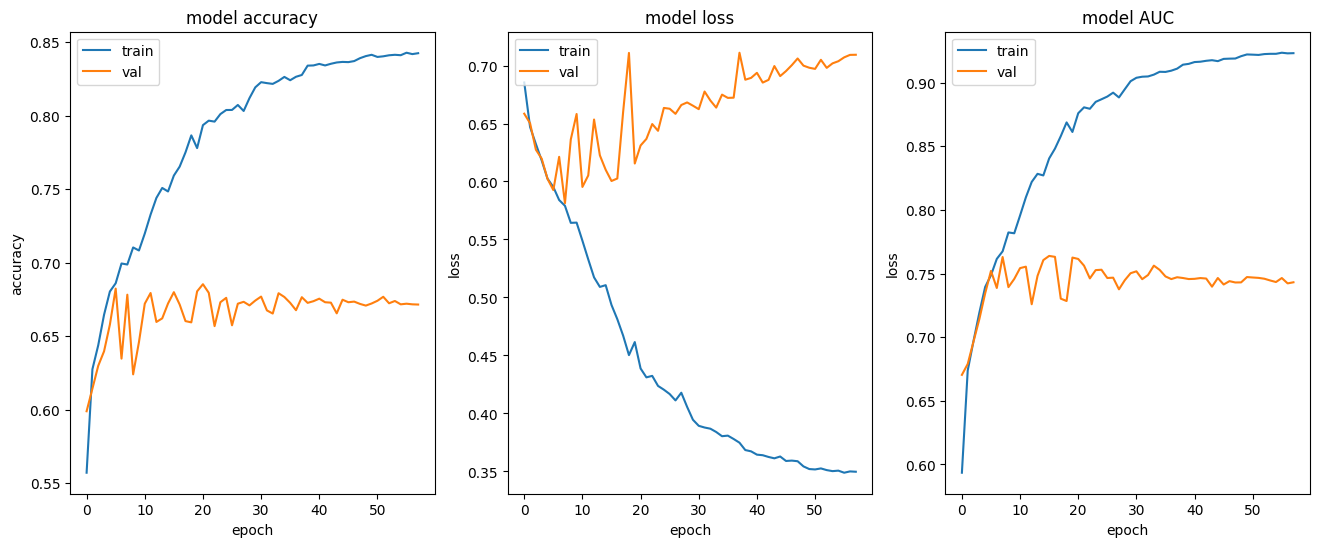

In [222]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.plot(history2.history['binary_accuracy'])
ax1.plot(history2.history['val_binary_accuracy'])
ax1.set_title('model accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend(['train', 'val'], loc='upper left')

ax2.plot(history2.history['loss'])
ax2.plot(history2.history['val_loss'])
ax2.set_title('model loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend(['train', 'val'], loc='upper left')

ax3.plot(history2.history['AUC'])
ax3.plot(history2.history['val_AUC'])
ax3.set_title('model AUC')
ax3.set_ylabel('loss')
ax3.set_xlabel('epoch')
ax3.legend(['train', 'val'], loc='upper left')

In [223]:
# Predicciones de probabilidades (forma: [N, 2])
y_pred_prob = model2.predict(val_ds_merge)

# Umbral de clasificación binaria
y_pred = (y_pred_prob > 0.5).astype(int)  # → binariza: >0.5 → 1, ≤0.5 → 0

y_true = []
for _, label_batch in val_ds_merge:
    y_true.append(label_batch.numpy())
y_true = np.concatenate(y_true, axis=0).astype(int)  # → [N, 2]

from sklearn.metrics import classification_report, multilabel_confusion_matrix

print("Crackles")
print(classification_report(y_true[:, 0], y_pred[:, 0], target_names=["No Crackles", "Crackles"]))

print("Wheezes")
print(classification_report(y_true[:, 1], y_pred[:, 1], target_names=["No Wheezes", "Wheezes"]))

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
Crackles
              precision    recall  f1-score   support

 No Crackles       0.57      0.70      0.63      1794
    Crackles       0.59      0.45      0.51      1713

    accuracy                           0.58      3507
   macro avg       0.58      0.58      0.57      3507
weighted avg       0.58      0.58      0.57      3507

Wheezes
              precision    recall  f1-score   support

  No Wheezes       0.80      0.79      0.79      1897
     Wheezes       0.75      0.76      0.76      1610

    accuracy                           0.78      3507
   macro avg       0.77      0.77      0.77      3507
weighted avg       0.78      0.78      0.78      3507



In [224]:
matches = np.all(y_pred == y_true, axis=1) 

exact_match_acc = np.mean(matches)

print(f"Exact Match Accuracy (Crackles y Wheezes juntos): {exact_match_acc:.4f}")

Exact Match Accuracy (Crackles y Wheezes juntos): 0.4183


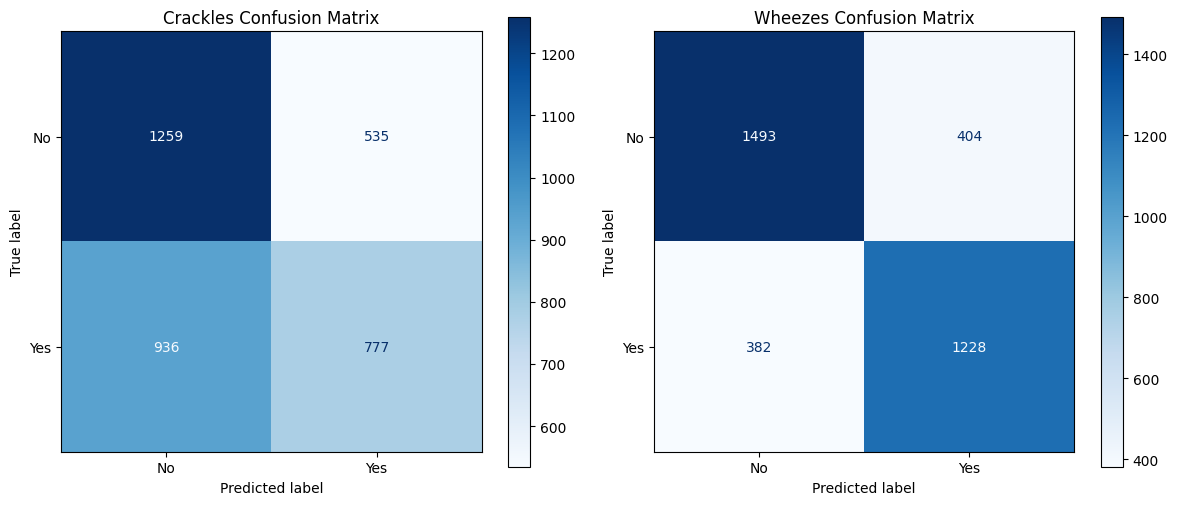

In [225]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener matrices por clase
cm = multilabel_confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, (cls_name, matrix) in enumerate(zip(["Crackles", "Wheezes"], cm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["No", "Yes"])
    disp.plot(ax=axs[i], cmap="Blues", values_format='d')
    axs[i].set_title(f"{cls_name} Confusion Matrix")

plt.tight_layout()
plt.show()


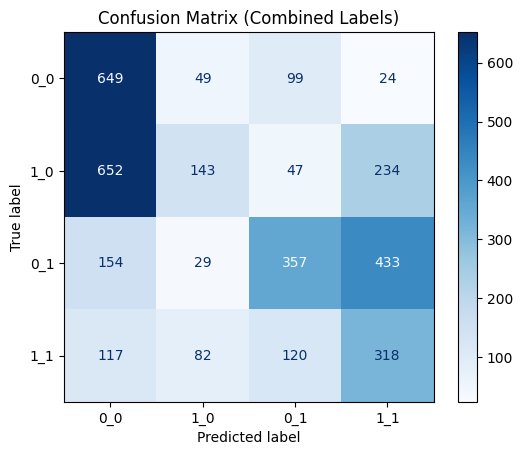

In [226]:
# Combinar las etiquetas binarias en una sola clase combinada
def combine_labels(y_bin):
    return [f"{a}_{b}" for a, b in y_bin]

labels_combined = ['0_0', '1_0', '0_1', '1_1']
y_true_comb = combine_labels(y_true)
y_pred_comb = combine_labels(y_pred)

cm = confusion_matrix(y_true_comb, y_pred_comb, labels=labels_combined)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_combined)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Combined Labels)")
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


/tmp/ipykernel_425353/129763499.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(features_2d[idx, 0], features_2d[idx, 1],


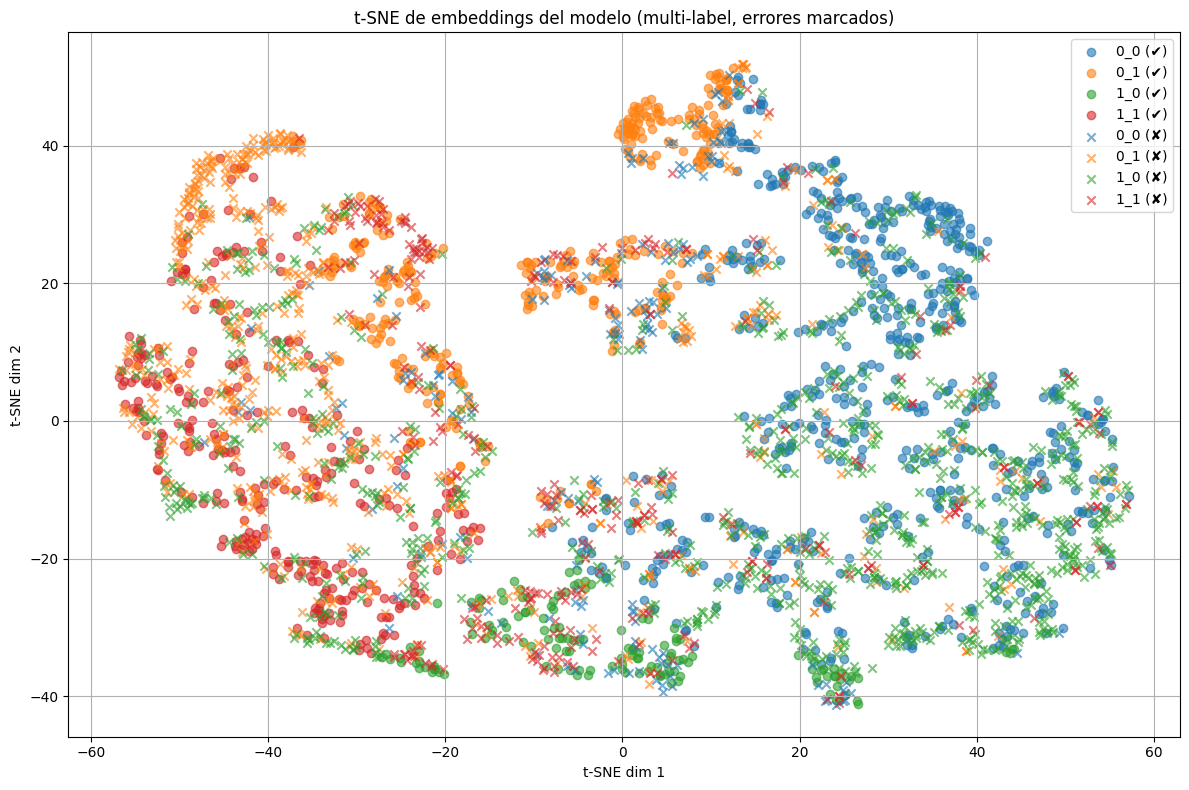

In [227]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf

# 1. Extraer embeddings desde la penúltima capa (ajusta el nombre si cambió)
feature_model = tf.keras.Model(inputs=model2.input, outputs=model2.get_layer("glu_output").output)
features = feature_model.predict(val_ds_merge, verbose=1)  # (N, feature_dim)

# 2. Obtener predicciones y etiquetas verdaderas
y_pred_prob = model2.predict(val_ds_merge)
y_pred_bin = (y_pred_prob > 0.5).astype(int)  # (N, 2)

y_true = []
for _, y in val_ds_merge:
    y_true.append(y.numpy())
y_true = np.vstack(y_true)  # (N, 2)

# 3. Codificar combinación de clases para visualización
def label_to_str(crackles, wheezes):
    return f"{int(crackles)}_{int(wheezes)}"

labels_str = [label_to_str(c, w) for c, w in y_true]
labels_pred_str = [label_to_str(c, w) for c, w in y_pred_bin]
errors = np.array(labels_str) != np.array(labels_pred_str)

# 4. t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
features_2d = tsne.fit_transform(features)

# 5. Visualización
plt.figure(figsize=(12, 8))
label_set = sorted(set(labels_str))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
color_map = {label: color for label, color in zip(label_set, colors)}

# Correctos
for label in label_set:
    idx = (np.array(labels_str) == label) & (~errors)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1],
                label=f"{label} (✔)", color=color_map[label],
                marker='o', alpha=0.6)

# Incorrectos
for label in label_set:
    idx = (np.array(labels_str) == label) & (errors)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1],
                label=f"{label} (✘)", color=color_map[label],
                marker='x', alpha=0.6, edgecolors='k')

plt.title("t-SNE de embeddings del modelo (multi-label, errores marcados)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
